In [74]:

import numpy as np
import sys, os
sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
# from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
# from astropy.wcs import utils as asutils
# from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, gaussian
# from skimage.io import imread, imshow
# from skimage.feature import peak_local_max
# from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh
from matplotlib.backends.backend_pdf import PdfPages
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
####List files in directory

model_dir='/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/ModelsMaps/finishedModels2/'
fit_dir = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'
files_in_directory = os.listdir(model_dir)


with open('injected-model-list.txt', 'w') as file:
    for filename in files_in_directory:
        file.write(filename + '\n')
files = [f for f in files_in_directory if os.path.isfile(os.path.join(model_dir, f))]
directory_count = sum(os.path.isdir(os.path.join(fit_dir, d)) for d in os.listdir(fit_dir))
print(f"Number of Model Files: {len(files)}")
print(f"Number of Model Directory: {directory_count}")

num = 1
run_numbers = np.linspace(1, 249, 249)
for run_number in run_numbers:
    try:
        catalog_results = f"{fit_dir}model_{int(run_number)}/fitResults/FinalRefit/model_{int(run_number)}_modelFit.yml"
        fitted_sources = parse_yaml_file(catalog_results)
    except FileNotFoundError:
        num = num+1
        skip_val = 1
print(f'Total Number of Fits with no Final Refit: {num} and with Final Refit: {directory_count-num}')

Number of Model Files: 249
Number of Model Directory: 249
Total Number of Fits with no Final Refit: 102 and with Final Refit: 147


In [117]:
run_number = 177
save_pdf=False

outdir = os.getcwd()+ '/simplots/'
if not os.path.exists(outdir):
    os.makedirs(outdir)

if save_pdf:
    from matplotlib.backends.backend_pdf import PdfPages
    pdf = PdfPages(os.path.join(outdir, f'run-{run_number}-plots.pdf')) 

run_number_str = str(run_number)
filename = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'+'model_'+run_number_str+'/initialMap/maps/map.fits'

injected_model_yaml = "injected-model-list.txt"
with open(injected_model_yaml, 'r') as filelist:
    lines=filelist.readlines()

ra_list=[]
dec_list = []
run_number_list = []
for i, run in enumerate(lines):
    run = run.strip()
    ra,dec = extract_ra_dec(run)
    run_number2 = extract_run(run)
    ra_list.append(ra)
    dec_list.append(dec)
    run_number_list.append(int(run_number2))

run_index = run_number_list.index(run_number)
ra_center = ra_list[run_index]
dec_center = dec_list[run_index]
ra_center = "{:.2f}".format(float(ra_center))
dec_center = "{:.2f}".format(float(dec_center))
model_file = model_dir + 'model_'+str(int(run_number))+'_roi_'+str(ra_center)+'_'+str(dec_center)+'.yaml'
print(model_file)
injected_sources = parse_yaml_file(model_file)
inj_names = [source['source_name'] for source in injected_sources]
ra_vals = [source['lon0'] for source in injected_sources]
dec_vals = [source['lat0'] for source in injected_sources]
ext_vals = [source['sigma'] for source in injected_sources]

try:
    catalog_results = f"{fit_dir}model_{int(run_number)}/fitResults/FinalRefit/model_{int(run_number)}_modelFit.yml"
    fitted_sources = parse_yaml_file(catalog_results)
    rec_names = [source['source_name'] for source in fitted_sources]
    rec_ra_vals = [source['lon0'] for source in fitted_sources]
    rec_dec_vals = [source['lat0'] for source in fitted_sources]
    rec_ext_vals = [source['sigma'] for source in fitted_sources]
except:
    catalog_results = f"{fit_dir}model_{int(run_number)}/models/curModel.model"
    fitted_sources = parse_model_file(catalog_results)
    rec_names = [source['name'] for source in fitted_sources]
    rec_ra_vals = [source['ra'] for source in fitted_sources]
    rec_dec_vals = [source['dec'] for source in fitted_sources]
    rec_ext_vals = [source['sigma'] for source in fitted_sources]

fig, ax = plt.subplots(figsize=(8.5, 11)) 
ax.axis('off') 
text = f"DRIPS Compilation of Result for Simulation Run {run_number} with (RA, Dec) = ({ra_center}, {dec_center})"
ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
if save_pdf:
    pdf.savefig(fig)  
plt.close(fig)

injected_sources = pd.DataFrame({
    "Name": inj_names, 
    "ra": ra_vals,
    "dec":  dec_vals, 
    "ext": ext_vals,
    })
alps_sources = pd.DataFrame({
    "Name": rec_names, 
    "ra": rec_ra_vals , 
    "dec":  rec_dec_vals, 
    "ext": rec_ext_vals
    })

/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/ModelsMaps/finishedModels2/model_177_roi_80.08_-3.55.yaml


ROI center 80.08, -3.55
ROI center in Celestial Coordintes = 80.08, -3.55
Loading Celestial Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---MOL' 'DEC--MOL' 
CRVAL : 80.08 -3.55 
CRPIX : 900.0 900.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00555555555555555 0.005555555555555556 
NAXIS : 1800  1800
Fits File loaded
Degrees per pixel: 0.005555555555555556 
Shape of Map in pixel number: 1800 X 1800
Degrees per pixel: 0.005555555555555556 
Peak intensity pixel location: (870, 588)
Peak intensity sky location: <SkyCoord (ICRS): (ra, dec) in deg
    (82.00307113, -3.69305703)>
Peak intensity value: 7.910469633092731
None
Shape of Map in pixel number: 1800 X 1800
Degrees per pixel: 0.005555555555555556 
Peak intensity pixel location: (870, 588)
Peak intensity sky location: <SkyCoord (ICRS): (ra, dec) in deg
    (82.00307113, -3.69305703)>
Peak intensity value: 7.910469633092731
None
Plotting contours [5, 6, 7]
Peak intensity pixel location: (870, 588)
Peak intensity sk

(312.6595586702246, 38.5338029703521)

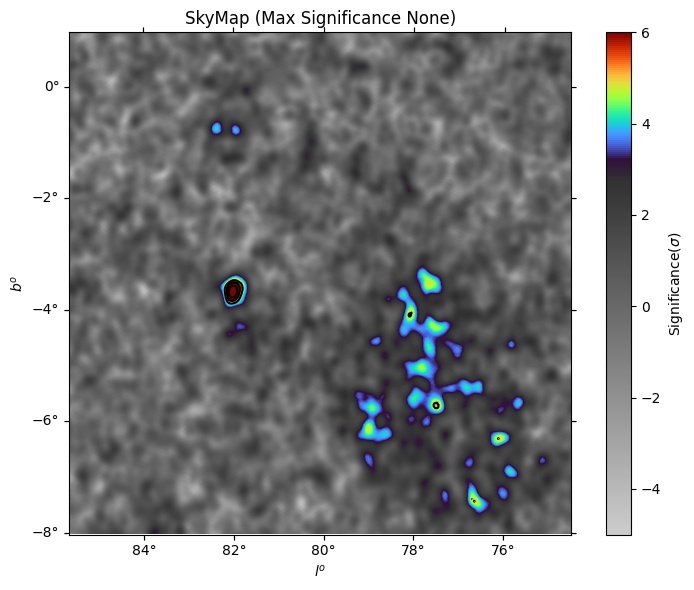

In [118]:
# Load the Simulation FITS file
filename = '/lustre/hawcz01/scratch/userspace/sgroetsch/source_fitting/4HWCv5/injectionStudy/fits/'+'model_'+run_number_str+'/initialMap/maps/map.fits'

print(f"ROI center {ra_center}, {dec_center}")
model_file = model_dir + '/model_'+str(run_number)+'_roi_'+str(ra_center)+'_'+str(dec_center)+'.yaml'

ra_center = float("{:.2f}".format(float(ra_center)))
dec_center = float("{:.2f}".format(float(dec_center)))
coord_sys = 'C'
# ra_center = 237
# dec_center = 61
# coord_sys = 'G'
xlength=5
ylength=5

array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, ra_center, dec_center, xlength, ylength, coord_sys)
print(f'Shape of Map in pixel number: {ynum} X {xnum}')
print(f'Degrees per pixel: {pixel_size} ')
max_signif=find_peak(array, wcs)
print(max_signif)
print(f'Shape of Map in pixel number: {ynum} X {xnum}')
print(f'Degrees per pixel: {pixel_size} ')
max_signif=find_peak(array, wcs)
print(max_signif)
fig, ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=6, contour=True, title=f'SkyMap (Max Significance {max_signif})', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
if save_pdf:
    pdf.savefig(fig)  
find_peak(array, wcs)
gal_to_cel(ra_center, dec_center)


Plotting contours [5, 6, 7]


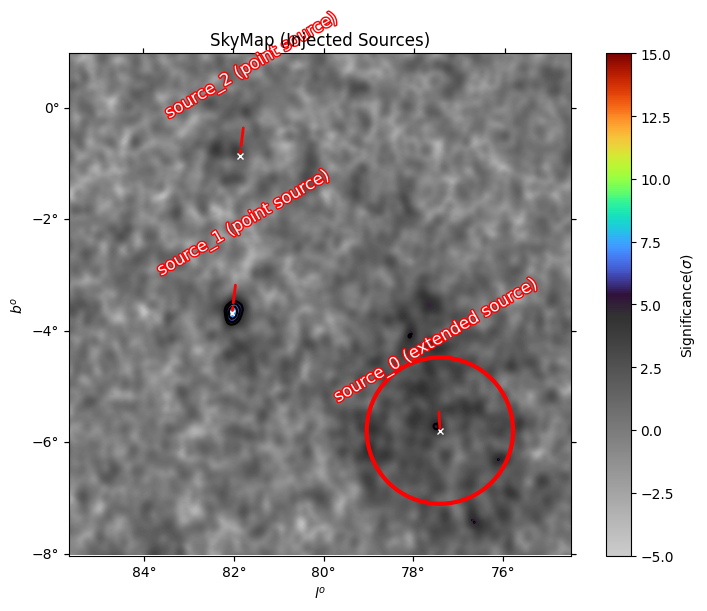

In [119]:
fig, ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=5, vmin=-5, vmax=15, contour=True, title=f'SkyMap (Injected Sources)', hotspots=injected_sources, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
if save_pdf:
    pdf.savefig(fig)  

Plotting contours [5, 6, 7]


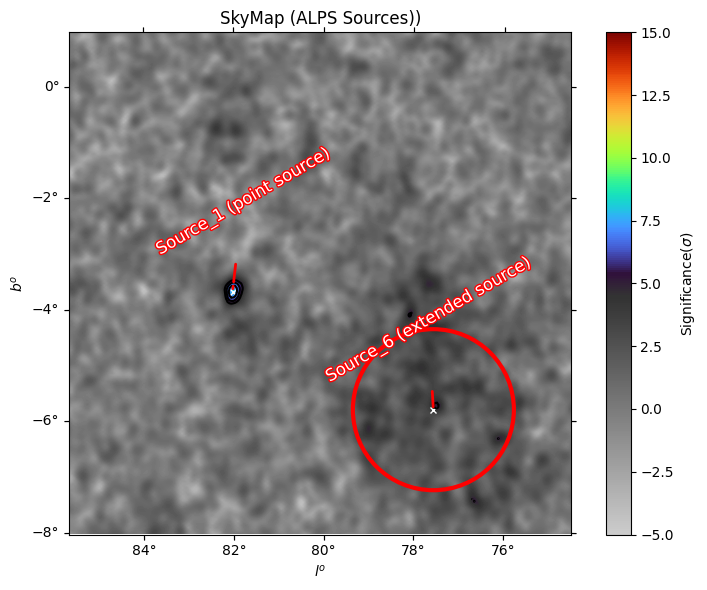

In [120]:
fig, ax=make_plots(array, wcs, pixel_size, coordsys='G', threshold=5, vmin=-5, vmax=15, contour=True, title=f'SkyMap (ALPS Sources))', hotspots=alps_sources, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
if save_pdf:
    pdf.savefig(fig)  

In [121]:
# Stop if there are no hotspots greater than 5 sigma
if np.max(array) < 5:
    print(f'Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)')
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
    ax.axis('off')  # Turn off axes
    text = f"Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
    plt.show()
    if save_pdf:
        pdf.savefig(fig)  
    exit
else:
    print(f'Algorithm will proceed. Significance Map has data greater than 4$\sigma$)')

Algorithm will proceed. Significance Map has data greater than 4$\sigma$)


Significant deviation from Gaussian on positive side at:108,  2.26221
Signal (mean excess): 3.03092
Noise (background RMS): 1.17568
SNR: 2.58
Peak SNR: 6.73
2 sigma deviation from Gaussian fit on positive side 2.35135
3 sigma deviation from Gaussian fit on positive side 2.35135
Mask deviation value: 2.26221, Sigma of Gaussian fit: 1.17568
Signal-to-noise ratio (SNR) metric based on deviation from Gaussian fit: 1.924178029988863
Signal-to-noise ratio (SNR) metric based blah: 2.5780224543288752


(2.2622094763962495, 2.3513515289532156, 3.5270272934298235)

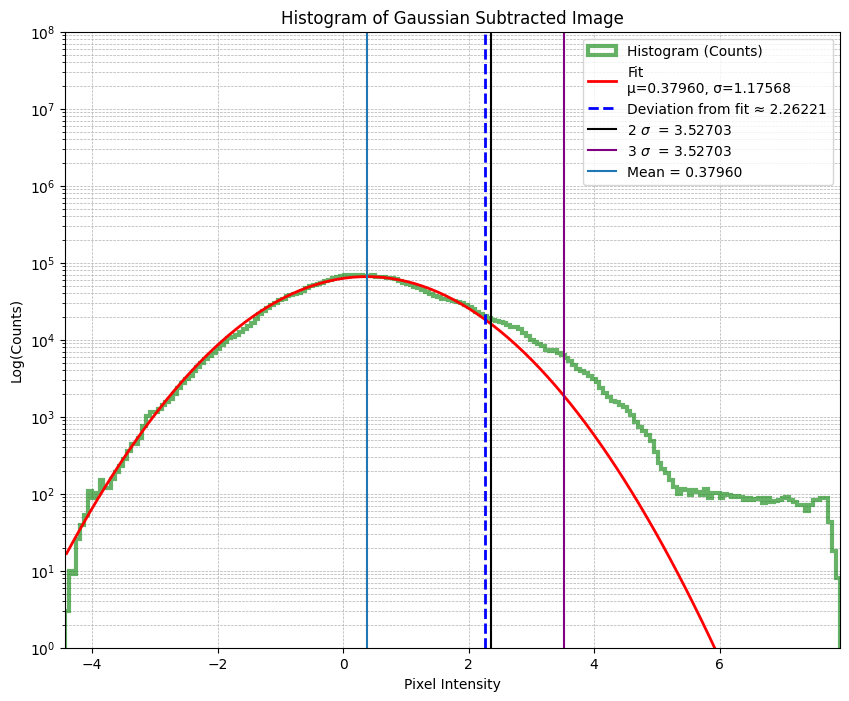

In [123]:
analyze_histogram(array, plot=True)

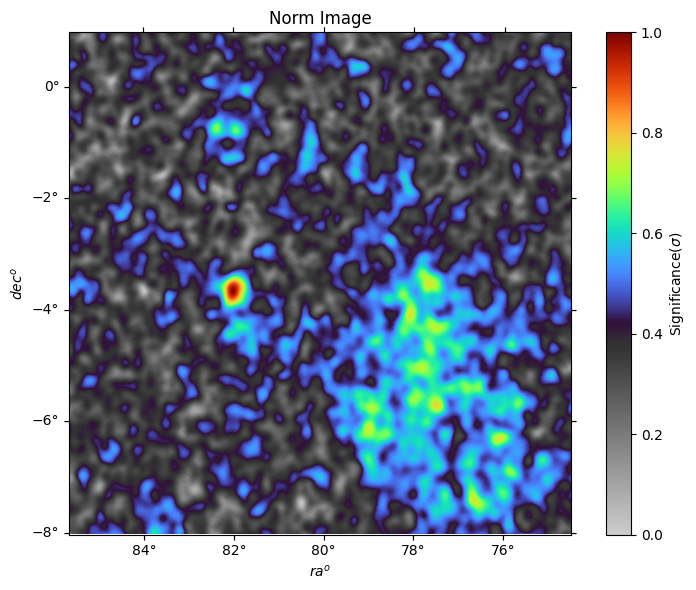

In [124]:
# #Normalize the image between 0 and 1 for analysis
image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
fig,ax=make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title='Norm Image', hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6))
if save_pdf:
    pdf.savefig(fig) 


Pixel Size=0.0056
Number of pixels corresponding to 0.25 smear radius = 45.00
Estimated background RMS: 0.05837674859632204
Number of point source blobs= 1
Number of point source blobs= 13
Blob Intensity 5.72563152154741, Coords (81.99067236503956 deg, -3.6780773344267876 deg), Radius 53.99999999999999, Pixel Radius 0.3
Blob Intensity 3.224730173578879, Coords (77.78438280855066 deg, -4.267420804226735 deg), Radius 115.2, Pixel Radius 0.64
Number of point source after filtering= 2
Pixel Size=0.0056
Number of pixels corresponding to 0.30 smear radius = 54.00
Estimated background RMS: 0.06233885649740357
Number of point source blobs= 1
Number of point source blobs= 13
Blob Intensity 5.72563152154741, Coords (81.99067236503956 deg, -3.6780773344267876 deg), Radius 53.99999999999999, Pixel Radius 0.3
Blob Intensity 3.2426640652450978, Coords (77.78429863869394 deg, -4.297432179191273 deg), Radius 115.2, Pixel Radius 0.64
Number of point source after filtering= 2
Pixel Size=0.0056
Number of

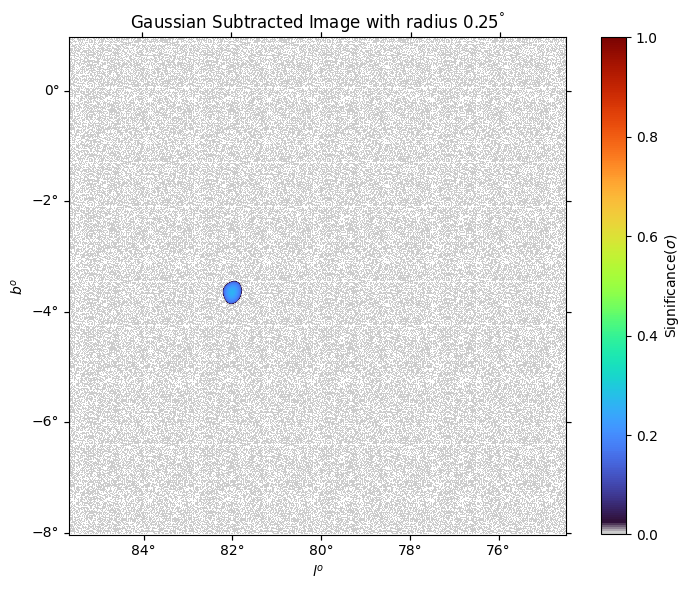

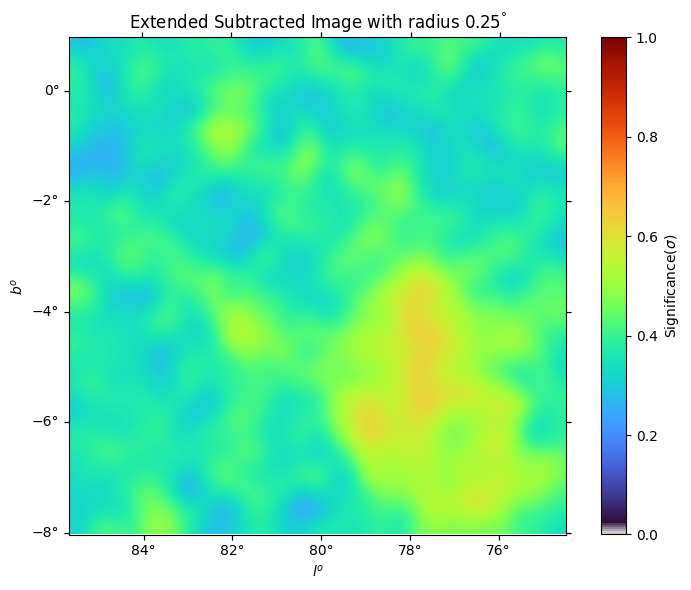

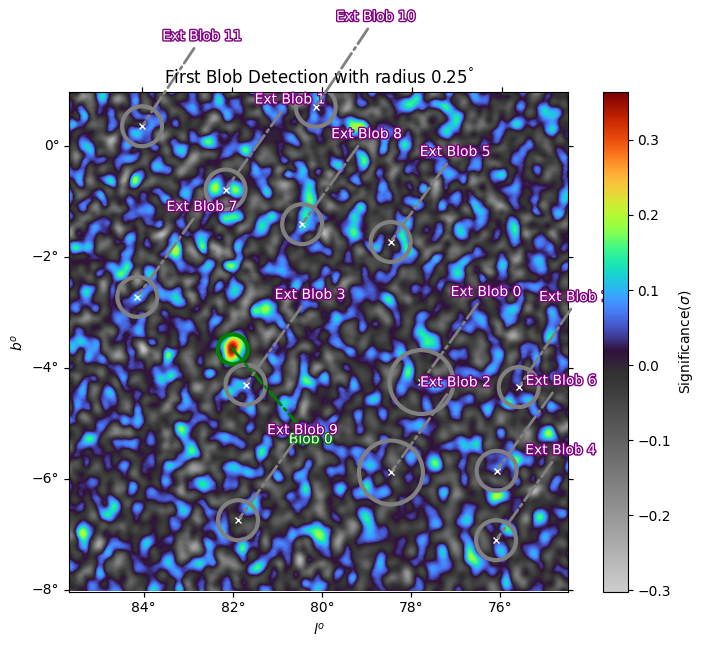

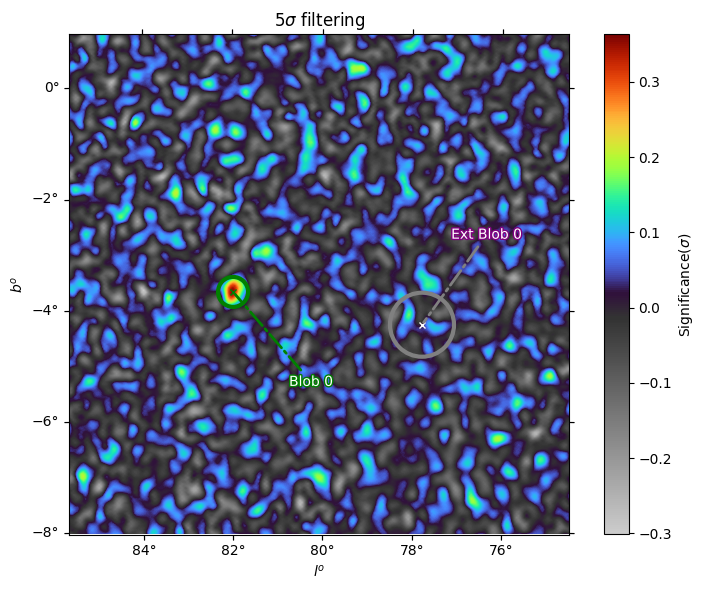

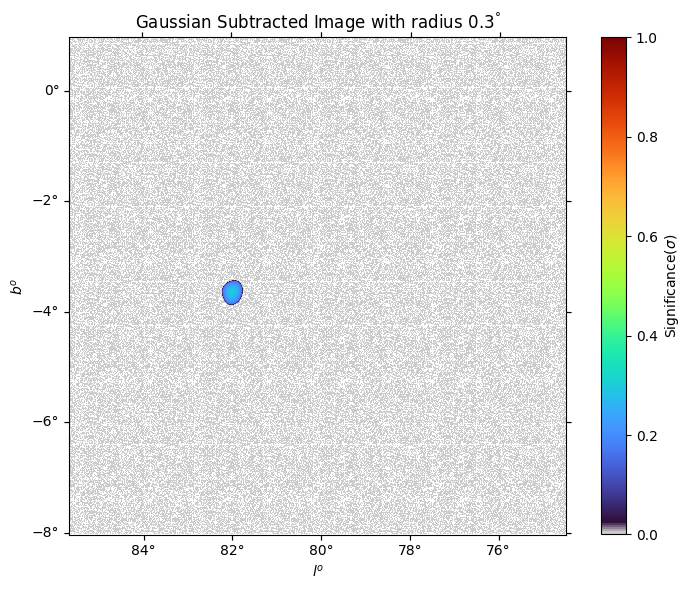

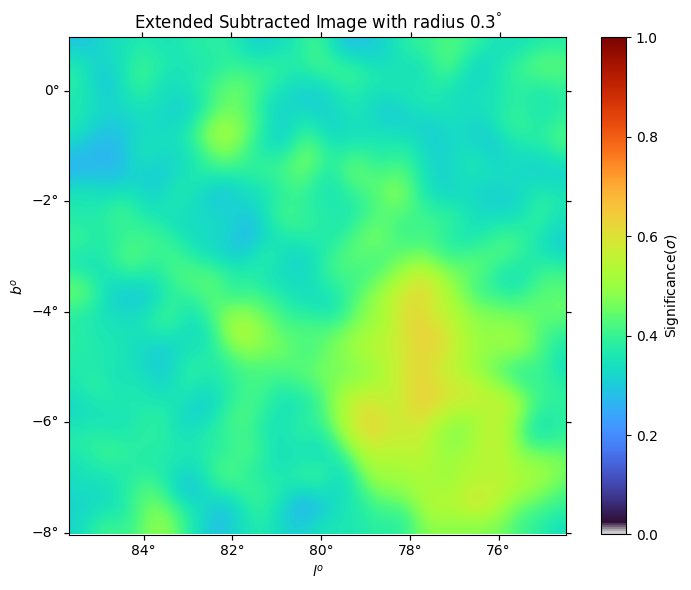

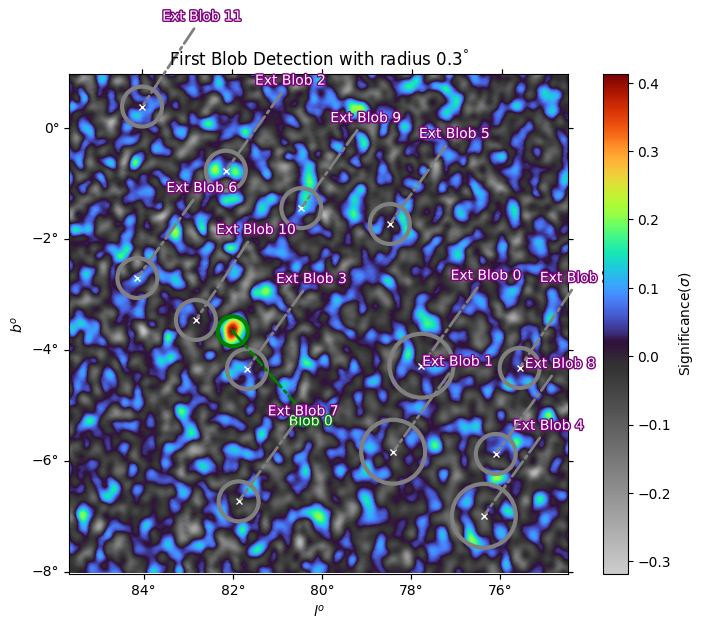

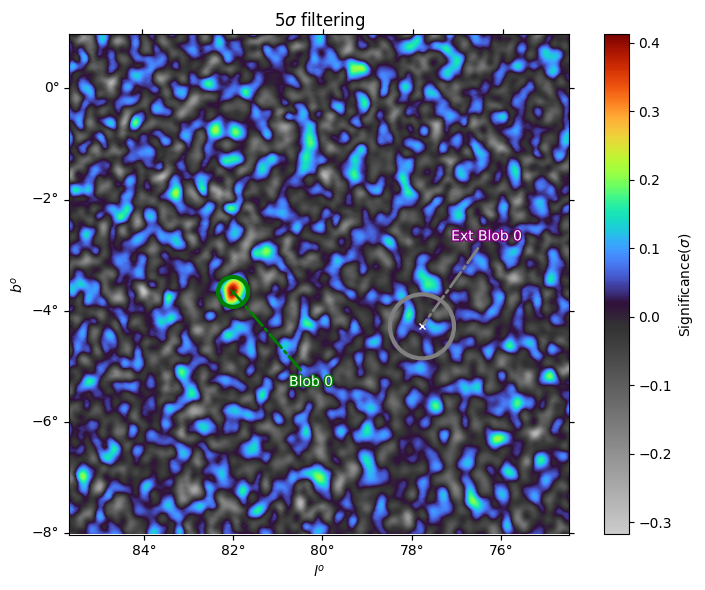

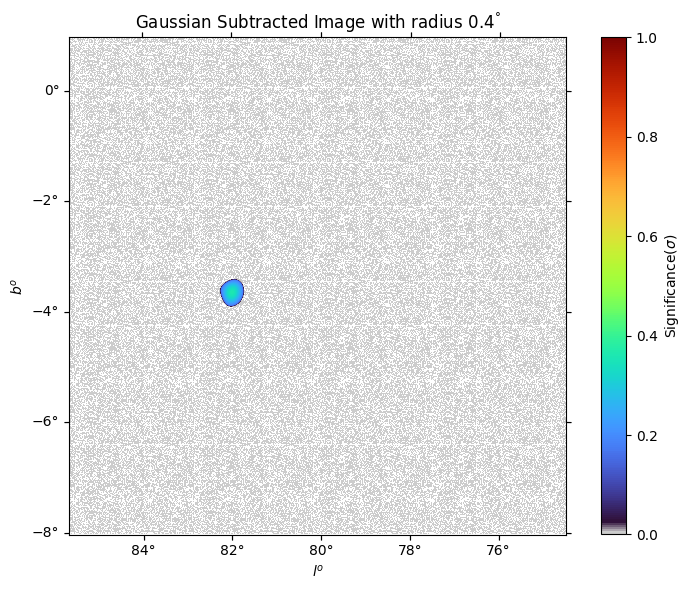

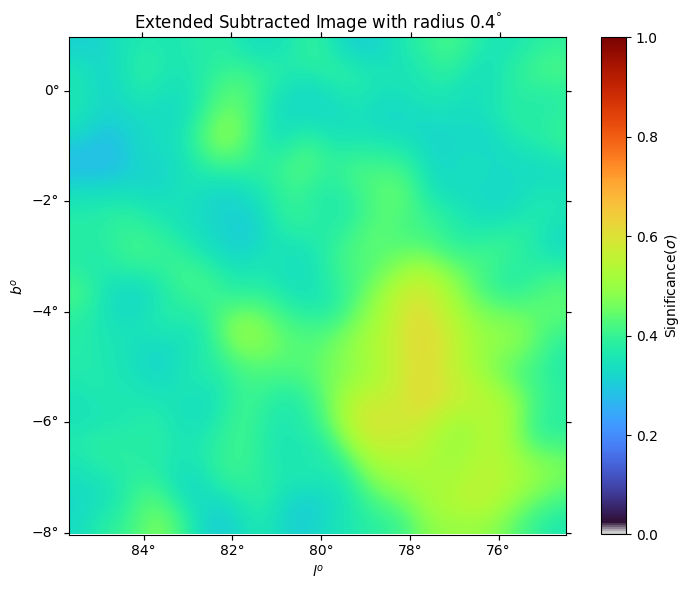

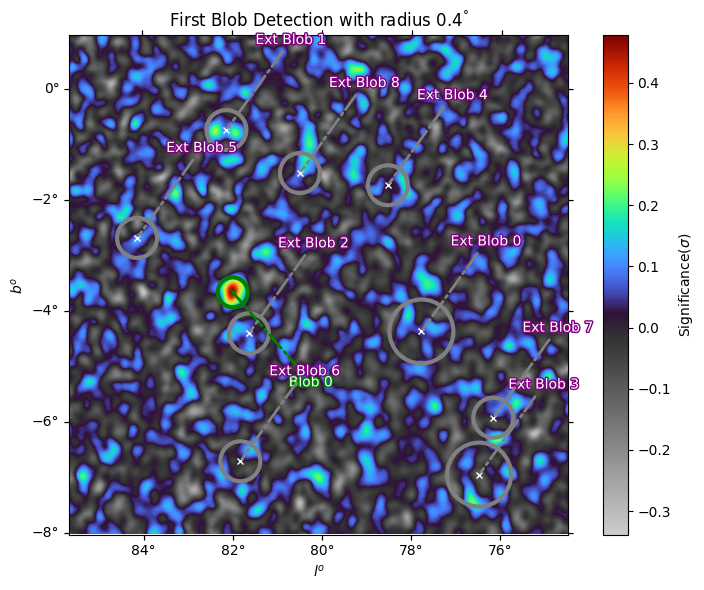

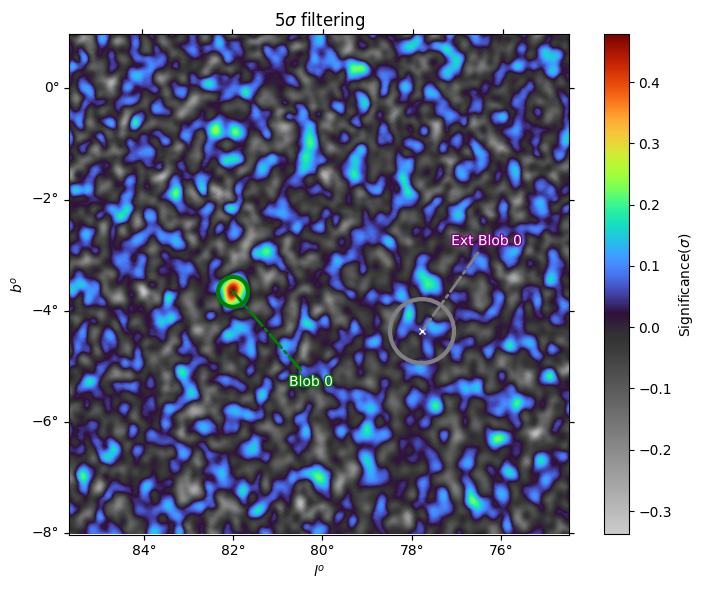

In [ ]:
all_ps_blobs = []
all_ext_blobs = []
all_pscoord_blobs = []
all_extcoord_blobs = []
all_psradius_blobs = []
all_extradius_blobs = []
# for radius in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
for radius in [0.25, 0.3,  0.4]:
    smear_radius=radius #PSF of the dec band
    print(f"Pixel Size={pixel_size:.4f}")
    print(f"Number of pixels corresponding to {smear_radius:.2f} smear radius = {smear_radius/pixel_size:.2f}")
    dog_image = difference_of_gaussians(norm_image, 1, smear_radius/pixel_size)
    import scipy.ndimage as ndi
    dog_low_noise = ndi.gaussian_filter(dog_image, sigma=18.0)

    from astropy.stats import sigma_clip
    import numpy as np

    def estimate_background_sigma(image, sigma=3, maxiters=5):
        clipped = sigma_clip(image, sigma=sigma, maxiters=maxiters)
        return np.std(clipped.data[~clipped.mask])

    sigma_resid = estimate_background_sigma(dog_image)
    print("Estimated background RMS:", sigma_resid)

    dog_final = np.where(dog_low_noise > 2.5 * sigma_resid, dog_low_noise, 0)
    dog_norm = (dog_final-np.min(dog_final))/(np.max(dog_final)-np.min(dog_final))

    extmap=gaussian_filter(norm_image-dog_norm, sigma=smear_radius/pixel_size)
    # mask_deviation_value, deviation_2sig, deviation_3sig= analyze_histogram(dog_final, plot=True)
    # fig,ax=make_plots(dog_final, wcs, pixel_size, coordsys='G', threshold=0.0000005,vmin=np.min(dog_final), vmax=np.max(dog_final), title=f'Gaussian Subtracted Image with radius {smear_radius}$^\degree$', cmap='ult')
    # fig,ax=make_plots(extmap, wcs, pixel_size, coordsys='G', threshold=0.0000005,vmin=np.min(extmap), vmax=np.max(extmap), title=f'Extended Subtracted Image with radius {smear_radius}$^\degree$', cmap='ult')

    fig,ax=make_plots(dog_final, wcs, pixel_size, coordsys='G', threshold=0.0000005,vmin=np.min(0), vmax=np.max(1), title=f'Gaussian Subtracted Image with radius {smear_radius}$^\degree$', cmap='ult')
    fig,ax=make_plots(extmap, wcs, pixel_size, coordsys='G', threshold=0.0000005,vmin=np.min(0), vmax=np.max(1), title=f'Extended Subtracted Image with radius {smear_radius}$^\degree$', cmap='ult')
    threshold_val = 0.01
    # ps_blobs = blob_dog(dog_final, min_sigma=0.1/pixel_size, max_sigma=smear_radius/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.5)
    ps_blobs_1 = blob_dog(dog_final, min_sigma=0.25/pixel_size,  max_sigma=0.39/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.7)
    ps_blobs_2 = blob_dog(extmap, min_sigma=0.4/pixel_size,  max_sigma=1/pixel_size, threshold=threshold_val, exclude_border=50, overlap=0.7)
    # ps_blobs = ps_blobs_1 + ps_blobs_2
    print("Number of point source blobs=",len(ps_blobs_1))
    print("Number of point source blobs=",len(ps_blobs_2))
    blobs_dict = {
        'psblobs': ps_blobs_1,
        'extblobs':ps_blobs_2
    }
    fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=None,blobs=blobs_dict,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'First Blob Detection with radius {smear_radius}$^\degree$', cmap='ult', labels=['4haawc'])
    ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs_1, array,5 , wcs, pixel_size)
    ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ps_blobs_2, array,3 , wcs, pixel_size)
    blobs_dict = {
        'psblobs': ps_filtered_blobs,
        'extblobs':ext_filtered_blobs
    }
    print(r"Number of point source after filtering=",len(ps_filtered_blobs)+len(ext_filtered_blobs))
    fig,ax=make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=None,blobs=blobs_dict,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'5$\sigma$ filtering', cmap='ult', labels=['4haawc'])
    if save_pdf:
        pdf.savefig(fig)
    if len(ps_filtered_blobs) > 0:
        all_ps_blobs.append(ps_filtered_blobs)
        all_pscoord_blobs.append(ps_filtered_coords)
        all_psradius_blobs.append(ps_filtered_radius)
    if len(ext_filtered_blobs) > 0:
        all_ps_blobs.append(ext_filtered_blobs)
        all_pscoord_blobs.append(ext_filtered_coords)
        all_psradius_blobs.append(ext_filtered_radius)

Combined point sources: 5 → After removing overlaps: 3


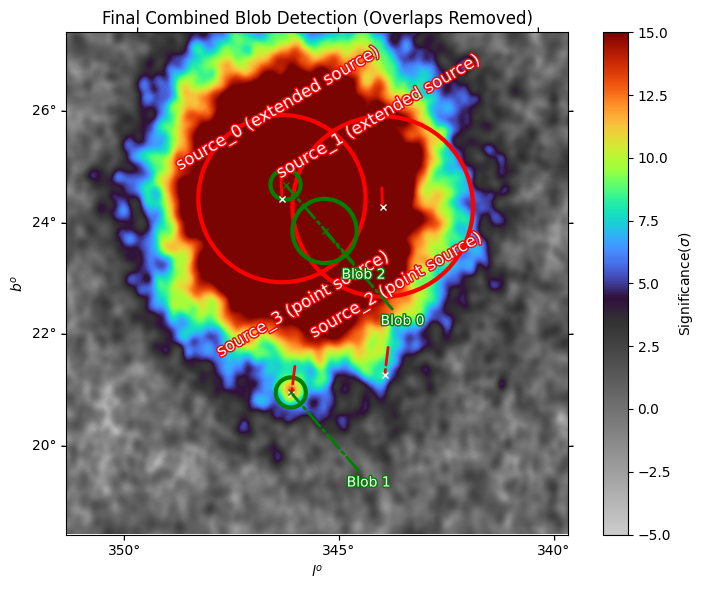

In [116]:
if len(all_ps_blobs) > 0:
    combined_ps_blobs = np.vstack(all_ps_blobs)
    # Flatten the list of lists of SkyCoord objects
    combined_pscoord_blobs = [coord for sublist in all_pscoord_blobs for coord in sublist]
    # Flatten the list of lists of radii values
    combined_psradius_blobs = [radius for sublist in all_psradius_blobs for radius in sublist]
else:
    combined_ps_blobs = np.array([]).reshape(0, 3)
    combined_pscoord_blobs = []
    combined_psradius_blobs = []

def remove_overlapping_blobs(blobs, coords, radii, overlap_threshold=0.5):
    """
    Remove overlapping blobs, keeping the one with larger radius.
    
    Parameters:
    -----------
    blobs : array of shape (n_blobs, 3)
        Each row: [y, x, radius]
    coords : list of SkyCoord objects
        Corresponding sky coordinates
    radii : list of float
        Corresponding radii values
    overlap_threshold : float
        Fraction of overlap to consider blobs as duplicates
    """
    if len(blobs) == 0:
        return blobs, coords, radii
    
    # Sort by radius (descending) to keep larger blobs
    sorted_indices = np.argsort(blobs[:, 2])[::-1]
    sorted_blobs = blobs[sorted_indices]
    sorted_coords = [coords[i] for i in sorted_indices]  # Reorder list
    sorted_radii = [radii[i] for i in sorted_indices]  # Reorder list
    
    keep_mask = np.ones(len(sorted_blobs), dtype=bool)
    
    for i in range(len(sorted_blobs)):
        if not keep_mask[i]:
            continue
        
        # Calculate distance to all other blobs
        distances = np.sqrt((sorted_blobs[i, 0] - sorted_blobs[:, 0])**2 + 
                           (sorted_blobs[i, 1] - sorted_blobs[:, 1])**2)
        
        # Check for overlap
        radii_sum = sorted_blobs[i, 2] + sorted_blobs[:, 2]
        overlap = (radii_sum - distances) / np.minimum(sorted_blobs[i, 2], sorted_blobs[:, 2])
        
        # Mark overlapping blobs (except itself) for removal
        keep_mask[overlap > overlap_threshold] = False
        keep_mask[i] = True  # Keep the current blob
    
    # Filter all arrays/lists by keep_mask
    filtered_blobs = sorted_blobs[keep_mask]
    filtered_coords = [coord for i, coord in enumerate(sorted_coords) if keep_mask[i]]
    filtered_radii = [radius for i, radius in enumerate(sorted_radii) if keep_mask[i]]
    
    return filtered_blobs, filtered_coords, filtered_radii

# Remove overlaps
final_ps_blobs, final_pscoords_blobs, final_psradius_blobs = remove_overlapping_blobs(
    combined_ps_blobs, combined_pscoord_blobs, combined_psradius_blobs)

print(f"Combined point sources: {len(combined_ps_blobs)} → After removing overlaps: {len(final_ps_blobs)}")

# Plot final results (only if there are blobs to plot)
if len(final_ps_blobs) > 0 :
    blobs_dict = {
        'psblobs': final_ps_blobs,
    }
    fig, ax = make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, hotspots=injected_sources,
                         title='Final Combined Blob Detection (Overlaps Removed)', cmap='ult', labels=['4hawc'])
    if save_pdf:
        pdf.savefig(fig)
else:
    print("No blobs found to plot")

In [38]:
blob_filter_intensity(final_ps_blobs, array,5 , wcs, pixel_size)

Blob Intensity 7.165385825685483, Coords (168.2200877655409 deg, 12.079954435102177 deg), Radius 115.2, Pixel Radius 0.64
Blob Intensity 8.340477630916373, Coords (165.87038202736213 deg, 13.706818718392444 deg), Radius 115.2, Pixel Radius 0.64
Blob Intensity 5.980673227731096, Coords (169.68220255685 deg, 11.648250690105668 deg), Radius 26.999999999999996, Pixel Radius 0.15
Blob Intensity 5.953697707460701, Coords (168.94890626639895 deg, 13.783452956816149 deg), Radius 26.999999999999996, Pixel Radius 0.15
Blob Intensity 13.9084357366204, Coords (165.3400346616345 deg, 15.073006940137025 deg), Radius 26.999999999999996, Pixel Radius 0.15


([array([1168. ,  551. ,  115.2]),
  array([ 984. , 1022. ,  115.2]),
  array([1342.,  346.,   27.]),
  array([1442.,  739.,   27.]),
  array([1043., 1278.,   27.])],
 [<SkyCoord (ICRS): (ra, dec) in deg
      (168.22008777, 12.07995444)>,
  <SkyCoord (ICRS): (ra, dec) in deg
      (165.87038203, 13.70681872)>,
  <SkyCoord (ICRS): (ra, dec) in deg
      (169.68220256, 11.64825069)>,
  <SkyCoord (ICRS): (ra, dec) in deg
      (168.94890627, 13.78345296)>,
  <SkyCoord (ICRS): (ra, dec) in deg
      (165.34003466, 15.07300694)>],
 [0.64, 0.64, 0.15, 0.15, 0.15])

In [64]:
def convert_sources(coords, radii, radius_to_sigma, name_prefix="Drip", source_type=None):
    """
    Convert blob coordinates and radii to a DataFrame.
    
    Parameters:
    -----------
    coords : list of SkyCoord objects
        Sky coordinates
    radii : list of float
        Radii values
    radius_to_sigma : function
        Function to convert radius to sigma
    name_prefix : str
        Prefix for source names
    source_type : str, optional
        Type of source ('PS' for point source, 'EXT' for extended source)
    
    Returns:
    --------
    df : pandas.DataFrame
        DataFrame with source information
    """
    df = pd.DataFrame({
        'Names': [f'{name_prefix}{i}' for i in range(len(coords))],
        'ra': [c.ra.deg for c in coords],
        'dec': [c.dec.deg for c in coords],
        'Circle Radius': radii,
    })
    df['Sigma Radius'] = [radius_to_sigma(r) for r in radii]
    
    if source_type is not None:
        df['Type'] = source_type
    
    return df

# print(f"  Point sources: {len(final_pscoords_blobs)}")
# print(f"  Extended sources: {len(final_extcoords_blobs)}")
# Convert point sources
ps_df = convert_sources(final_pscoords_blobs, final_psradius_blobs, 
                        radius_to_sigma, name_prefix="DripPS", source_type="PS")



# Combine into single DataFrame
filtered_df = ps_df

print(f"\nFinal DataFrame:")
print(f"  Total sources: {len(filtered_df)}")
print(f"  Point sources: {len(ps_df)}")
# print(f"  Extended sources: {len(ext_df)}")
print("\nDataFrame preview:")
print(filtered_df.head(10))


Final DataFrame:
  Total sources: 18
  Point sources: 18

DataFrame preview:
     Names          ra        dec  Circle Radius  Sigma Radius Type
0  DripPS0  282.102981  -1.707492           0.24      0.158395   PS
1  DripPS1  279.351941  -6.869971           0.24      0.158395   PS
2  DripPS2  279.825636  -5.825046           0.24      0.158395   PS
3  DripPS3  280.958226  -3.425409           0.24      0.158395   PS
4  DripPS4  276.481728 -13.613721           0.24      0.158395   PS
5  DripPS5  277.834942  -9.796615           0.24      0.158395   PS
6  DripPS6  280.453425  -5.315703           0.24      0.158395   PS
7  DripPS7  278.634465  -8.629005           0.24      0.158395   PS
8  DripPS8  273.332368 -12.752659           0.24      0.158395   PS
9  DripPS9  283.046608  -0.048754           0.15      0.098997   PS


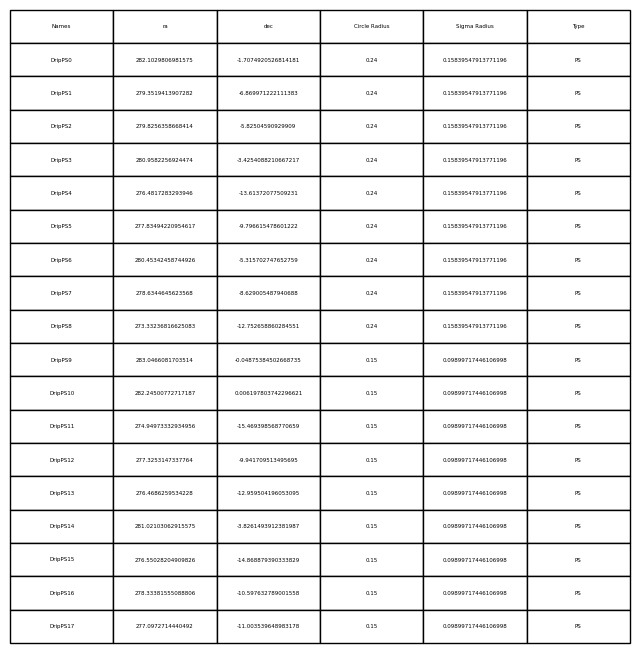

In [65]:
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
if save_pdf:
    pdf.savefig(fig)
plt.show()
plt.close(fig)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
43.199999999999996
43.199999999999996
43.199999999999996
43.199999999999996
43.199999999999996
43.199999999999996
43.199999999999996
43.199999999999996
43.199999999999996
26.999999999999996
26.999999999999996
26.999999999999996
26.999999999999996
26.999999999999996
26.999999999999996
26.999999999999996
26.999999999999996
26.999999999999996


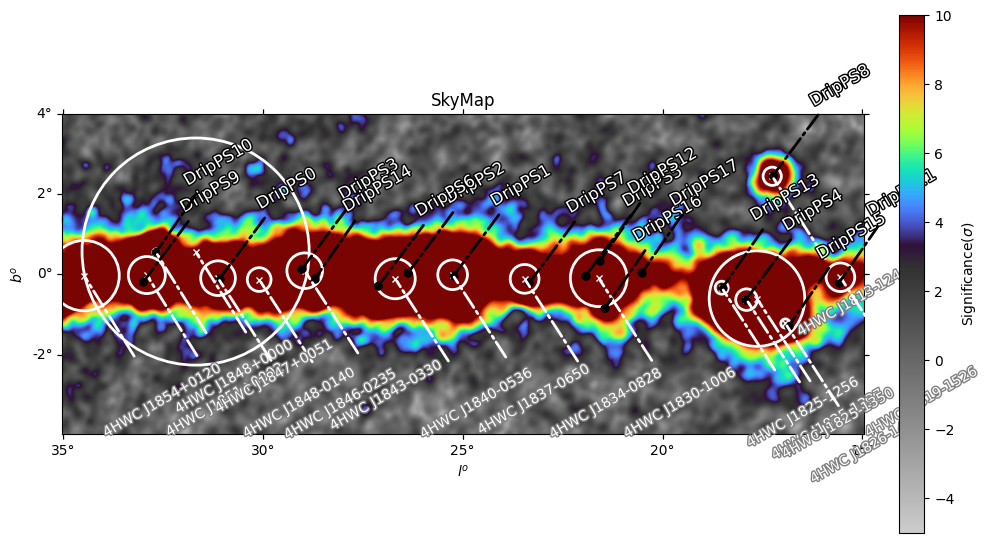

In [66]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    # "ext": filtered_df['Sigma Radius'],
    "ext": filtered_df['Circle Radius'],
    })
name = ['ic443 ps', 'halo ext']
ra = [94.42, 93.67]
dec = [22.35, 22.22]
ext = [0.01, 1.05]
hotspots2 = pd.DataFrame({
    "Name": name, 
    "ra": ra,
    "dec":  dec, 
    "ext": ext,
    })

fig,ax=make_plots(array, wcs, pixel_size,threshold=3, vmin=-5, vmax=10,  coordsys='G',hotspots=None, hotspots2=None, title=f'SkyMap', cmap='ult', labels=['4hawc', '1lhaaaso', '4fagl', 'sanr', 'pulsaar'])

for i in range(len(seed_final)):
    coord2 = SkyCoord(ra=filtered_df['ra'][i]*u.deg, dec=filtered_df['dec'][i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = filtered_df['Circle Radius'][i] / pixel_size
    print(r)
    if i%2 == 0:
        if r > 50:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=30, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=30, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    else:
        if r > 50:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='purple')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='purple', linewidth=2, 
            linestyle='-.'), color='white', rotation=30, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="purple")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='purple', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='black')
            ax.annotate(filtered_df['Names'][i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='black', linewidth=2, 
            linestyle='-.'), color='white', rotation=30, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="black")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='black', linewidth=3, fill=False)
    ax.add_patch(c)

for i in range(len(hotspots2)):
    coord2 = SkyCoord(ra=ra[i]*u.deg, dec=dec[i]*u.deg)
    pixelcoord = astropy_utils.skycoord_to_pixel(coord2, wcs)
    r = 2*ext[i] / pixel_size
    # print(r)
    if i%2 == 0:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 90), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 150), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    else:
        if r > 100:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 120), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), r, color='green', linewidth=3, fill=False)
        else:
            ax.plot(pixelcoord[0], pixelcoord[1], marker='o', markersize=5, color='green')
            ax.annotate(name[i],xy=(pixelcoord[0], pixelcoord[1]), xycoords='data', fontsize=12, xytext=(100, 160), 
            textcoords='offset pixels', arrowprops=dict(arrowstyle="-",color='green', linewidth=2, 
            linestyle='-.'), color='white', rotation=0, ha='right', va='center' ,
            path_effects=[pe.withStroke(linewidth=2, foreground="green")])
            c = plt.Circle((pixelcoord[0], pixelcoord[1]), 10, color='green', linewidth=3, fill=False)
    ax.add_patch(c)


if save_pdf:
    pdf.savefig(fig)
    pdf.close()